# Trabalho Grau B - Reconhecimento de imagem e transfer learning

## Integrantes

- Arthur Schallenberger
- Giovani de Souza
- Leonardo Fronza
- Renan Milech Pereira

---

**Docente:** Prof. Gabriel de Oliveira Ramos

## 2.1 Descrição do Problema e Dataset

### 2.1.1 Descrição do Problema

O problema abordado neste trabalho é a **classificação multiclasse de imagens de bolas esportivas**. Dado um conjunto de imagens coloridas, o objetivo é treinar um modelo capaz de identificar corretamente a qual modalidade esportiva pertence a bola presente na imagem, dentre 15 categorias distintas.

Trata-se de um problema de **visão computacional supervisionada**, onde cada imagem possui um único rótulo associado (classe da bola). O desafio central está na variação visual entre as classes: algumas bolas possuem formas, texturas e padrões muito distintos (como a bola de futebol americano e a de tênis de mesa), enquanto outras apresentam características visuais bem parecidas (como cricket, hockey e tênis), o que exige que o modelo aprenda representações que consigam separar essas classes com clareza.

A escolha desse domínio foi motivada pela disponibilidade de dados rotulados e pela aplicabilidade prática em sistemas de análise de transmissões esportivas, arbitragem automatizada e catalogação de conteúdo multimídia.

---

### 2.1.2 Dataset

O dataset utilizado é o **Sports Ball Image Recognition**, disponível publicamente no [Kaggle](https://www.kaggle.com/). Ele é composto por imagens JPEG de bolas de 15 modalidades esportivas, organizadas em subpastas por classe e divididas entre conjuntos de treino e teste.

#### Estrutura de diretórios

```
archive/
├── train/
│   ├── american_football/
│   ├── baseball/
│   ├── ...
│   └── volleyball/
└── test/
    ├── american_football/
    ├── baseball/
    ├── ...
    └── volleyball/
```

#### Classes e distribuição de imagens

O dataset contém **15 classes**, com a seguinte distribuição por split:

| Classe               | Treino | Teste | Total |
|----------------------|--------|-------|-------|
| american_football    | 384    | 96    | 480   |
| baseball             | 400    | 100   | 500   |
| basketball           | 340    | 86    | 426   |
| billiard_ball        | 646    | 162   | 808   |
| bowling_ball         | 440    | 111   | 551   |
| cricket_ball         | 581    | 146   | 727   |
| football             | 604    | 151   | 755   |
| golf_ball            | 549    | 138   | 687   |
| hockey_ball          | 530    | 133   | 663   |
| hockey_puck          | 390    | 98    | 488   |
| rugby_ball           | 493    | 124   | 617   |
| shuttlecock          | 429    | 108   | 537   |
| table_tennis_ball    | 620    | 156   | 776   |
| tennis_ball          | 490    | 123   | 613   |
| volleyball           | 432    | 109   | 541   |
| **Total**            | **7.328** | **1.841** | **9.169** |

A divisão treino/teste segue uma proporção aproximada de **80%/20%**, padrão comum em benchmarks de visão computacional.

#### Características das imagens

- **Formato:** JPEG (`.jpg`)
- **Resolução:** variada, desde 225x225 até resoluções maiores como 1920x1080
- **Canais:** RGB (3 canais)
- **Pré-processamento:** todas as imagens foram redimensionadas para **224x224 pixels**, tamanho de entrada da EfficientNetB0 e também usado na CNN própria para padronizar os experimentos

#### Balanceamento das classes

O dataset tem um **leve desbalanceamento** entre as classes. A classe com mais amostras (*billiard_ball*) tem 808 imagens, enquanto a menor (*basketball*) tem 426, uma diferença de aproximadamente 1,9x. Esse desbalanceamento é moderado e não exige técnicas agressivas de reamostragem, mas foi monitorado pelas métricas por classe (precisão, revocação e F1-score).


## 2.2 Análise das Classes e Dados

O dataset utilizado é o `sports-balls-multiclass-image-classification` do Kaggle, com imagens organizadas por subpasta de classe dentro de `DATASET/archive`.

**Visão geral:**
- 15 classes no total
- 7.328 imagens de treino
- Distribuição por classe varia entre ~340 e ~646 imagens (desbalanceamento leve)
- Resolução média de aproximadamente 606x509 pixels
- Nenhuma imagem corrompida encontrada no conjunto de treino

**Organização dos dados:**

Os arquivos estão em subpastas por rótulo (`DATASET/archive/train/<classe>`), o que facilita a associação imagem/rótulo e torna os experimentos fáceis de reproduzir.

**Observações sobre as imagens:**

As imagens têm bastante variação: fundos diferentes, iluminações distintas e o tamanho da bola no frame muda muito de uma imagem para outra. Algumas classes são visualmente parecidas, como `football` e `rugby_ball`, ou `hockey_ball` e `hockey_puck`, o que cria um desafio real para o modelo aprender a diferenciar.

**Por que escolhemos esses modelos:**

Dado o volume de dados e a diversidade visual do dataset, modelos pré-treinados são uma escolha natural. A EfficientNetB0 já foi treinada no ImageNet com mais de 1 milhão de imagens, o que significa que ela já sabe reconhecer bordas, texturas e formas básicas. Isso é exatamente o que precisamos para identificar bolas. Usamos também a CNN própria (SE-ResNet-34) para medir o quanto conseguimos chegar sem usar pesos pré-treinados.


## 2.3 Pré-processamento

O pré-processamento padroniza as imagens antes do treinamento e aplica augmentação para melhorar a generalização dos modelos.

### 2.3.1 Redimensionamento

Todas as imagens são redimensionadas para **224 x 224 pixels**, que é o tamanho de entrada da EfficientNetB0 (treinada no ImageNet) e adotado também na CNN própria para deixar os experimentos padronizados. O redimensionamento é feito no pipeline `tf.data`, sem alterar os arquivos originais.

### 2.3.2 Normalização

Cada modelo usa uma normalização diferente, porque cada um foi treinado com uma escala de pixels específica:

| Modelo         | Função de normalização                             | Intervalo de saída |
|----------------|----------------------------------------------------|-----------------|
| CNN própria    | `rescale = 1 / 255`                                | [0, 1]          |
| EfficientNetB0 | `efficientnet.preprocess_input`                    | Centrado em 0 (ImageNet) |

Usar o `preprocess_input` específico da EfficientNetB0 é fundamental para não degradar os pesos pré-treinados do ImageNet.

### 2.3.3 Divisão Treino / Validação / Teste

O dataset já vem com separação entre `train/` e `test/`. Reservamos **10%** das amostras de treino para validação, com semente fixa (`SEED = 42`) para reproducibilidade:

| Conjunto  | Origem                  | Imagens (aprox.) |
|-----------|-------------------------|-----------------|
| Treino    | `archive/train/` (90 %) | ~6.595           |
| Validação | `archive/train/` (10 %) | ~733             |
| Teste     | `archive/test/`         | 1.841            |

### 2.3.4 Augmentação de Dados

As transformações abaixo são aplicadas **só nas imagens de treino**. Validação e teste recebem apenas a normalização.

| Transformação       | Parâmetro          | Justificativa                                         |
|---------------------|--------------------|-------------------------------------------------------|
| Rotação 90°         | 0°/90°/180°/270°   | Bolas são circulares e simétricas em todas as rotações |
| Flip horizontal/vertical | Ativado       | Duplica a diversidade de orientações sem custo         |
| Deslocamento H / V  | ±10 %              | Robustez ao posicionamento da bola no frame           |
| Zoom                | 0.85x - 1.10x      | Robustez à escala (bola mais perto ou mais longe)     |
| Color jitter        | Brilho, contraste, saturação, hue | Robustez a iluminação e câmera      |
| Cutout              | p=0.5, max 56px    | Força o modelo a aprender a bola inteira, não só um patch |

As augmentações de rotação são especialmente importantes aqui porque bolas são objetos simétricos que aparecem em qualquer orientação.


## 2.4 Arquitetura das Redes Neurais

Para o trabalho, usamos duas abordagens complementares: uma CNN construída do zero como linha de base, e a EfficientNetB0 com transfer learning.

### 2.4.1 CNN própria

A CNN própria foi desenvolvida para servir como referência. A arquitetura segue a lógica de extração progressiva de características:

- **Entrada:** imagens 224x224x3
- **Blocos convolucionais:** 3 blocos com convoluções 2D, ativação ReLU e padding igual
- **Pooling:** MaxPooling2D após cada bloco para reduzir dimensionalidade
- **Regularização:** Dropout entre blocos para reduzir overfitting
- **Classificação:** camadas densas com softmax na saída, um neurônio por classe

Na prática, implementamos uma **SE-ResNet-34** treinada do zero, com blocos residuais e atenção de canal (Squeeze-and-Excitation), que é consideravelmente mais poderosa que uma CNN simples mas ainda parte totalmente dos pesos zerados.

### 2.4.2 Transfer Learning com EfficientNetB0

A rede escolhida para transfer learning foi a **EfficientNetB0**, que tem bom equilíbrio entre desempenho e custo computacional. A estratégia adotada foi:

1. Carregar os pesos pré-treinados no ImageNet
2. Congelar a base convolucional na fase inicial
3. Adicionar uma cabeça de classificação específica para as 15 classes do dataset
4. Descongelar as últimas camadas da base para fine-tuning numa segunda fase

### 2.4.3 Por que EfficientNetB0?

- A **CNN própria (SE-ResNet-34)** funciona como baseline para medir o quanto conseguimos sem nenhum conhecimento prévio
- A **EfficientNetB0** usa compound scaling (equilibra profundidade, largura e resolução) e entrega boa acurácia com parâmetros relativamente poucos
- A ativação **Swish** da EfficientNet costuma performar melhor que ReLU em tasks de visão
- Com apenas ~5,3M de parâmetros, a EfficientNetB0 roda sem problemas no Colab

### 2.4.4 Comparação das arquiteturas

| Arquitetura | Treinamento | Convoluções | Pooling | Vantagem principal |
| --- | --- | --- | --- | --- |
| SE-ResNet-34 | Do zero | 3x3 + SE blocks | GlobalAveragePooling2D | Baseline sem transfer learning |
| EfficientNetB0 | Transfer learning (ImageNet) | Compound scaling | GlobalAveragePooling2D | Melhor acurácia, menos épocas |

### 2.4.5 Fluxo do experimento

```
Imagem 224x224x3
        |
        +----> SE-ResNet-34 (do zero, AdamW, cosine LR) ----> Softmax (15 classes)
        |
        +----> EfficientNetB0 (ImageNet + fine-tuning) ------> Softmax (15 classes)
```

A CNN própria serve como ponto de referência e a EfficientNetB0 representa o ganho que o transfer learning traz para o problema.


# 3 CNN própria

Esta seção apresenta a arquitetura CNN desenvolvida "do zero" para o conjunto de dados.

## 3.1 Objetivos
- Propor uma arquitetura simples e eficiente para classificação das 15 classes de bola.
- Fornecer justificativa arquitetural e um resumo do modelo.

## 3.2 Arquitetura proposta
- Entrada: imagens redimensionadas para `224x224x3`.
- Bloco 1: Conv(32,3x3) -> ReLU -> Conv(32,3x3) -> ReLU -> MaxPool(2x2) -> Dropout(0.25)
- Bloco 2: Conv(64,3x3) -> ReLU -> Conv(64,3x3) -> ReLU -> MaxPool(2x2) -> Dropout(0.25)
- Bloco 3: Conv(128,3x3) -> ReLU -> MaxPool(2x2) -> Dropout(0.25)
- Classificador: **GlobalAveragePooling2D** -> Dense(256) -> ReLU -> Dropout(0.5) -> Dense(num_classes) -> Softmax

## 3.3 Justificativa arquitetural
- Profundidade moderada para evitar overfitting e manter custo computacional baixo.
- Crescimento de filtros por bloco (32→64→128) para capturar features de complexidade crescente.
- Pares de convoluções nos primeiros blocos inspirados em VGG para maior capacidade representacional.
- MaxPooling reduz dimensionalidade espacial; Dropout controla overfitting.
- **GlobalAveragePooling2D** em vez de Flatten: reduz parâmetros, melhora generalização e é invariante a pequenas translações.

O código abaixo define a arquitetura e exibe o `model.summary()`.


In [ ]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf


# ==================================================
# SE-ResNet-34 TREINADO DO ZERO
# ==================================================

def se_block(x, reduction=16):
    """Squeeze-and-Excitation: recalibra feature maps por canal.

    Permite que o modelo aprenda QUAIS canais são mais relevantes
    para cada imagem, melhorando significativamente a discriminação
    entre classes similares (e.g., soccer ball vs volleyball).
    """
    filters = x.shape[-1]
    # Squeeze: pooling global → vetor de canal
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1, 1, filters))(se)
    # Excitation: bottleneck FC → sigmoid por canal
    se = layers.Dense(max(filters // reduction, 8), activation='relu',  use_bias=False)(se)
    se = layers.Dense(filters,                      activation='sigmoid', use_bias=False)(se)
    return layers.Multiply()([x, se])


def residual_block(x, filters, stride=1, l2_reg=1e-4, projection=False):
    """Bloco residual 3x3→3x3 com Squeeze-and-Excitation."""
    reg      = regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    shortcut = x

    y = layers.Conv2D(filters, (3, 3), strides=stride, padding='same',
                      kernel_regularizer=reg, use_bias=False)(x)
    y = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)(y)
    y = layers.Activation('relu')(y)

    y = layers.Conv2D(filters, (3, 3), padding='same',
                      kernel_regularizer=reg, use_bias=False)(y)
    y = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)(y)

    # Atenção de canal (SE)
    y = se_block(y, reduction=16)

    if projection or stride != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same',
                                 kernel_regularizer=reg, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)(shortcut)

    y = layers.Add()([shortcut, y])
    y = layers.Activation('relu')(y)
    return y


def build_model(input_shape=(224, 224, 3), num_classes=15, dropout_rate=0.4, l2_reg=1e-4):
    """SE-ResNet-34 treinado do zero — estrutura 3-4-6-3 com atenção SE.

    Por que supera o baseline:
    - SE blocks: o modelo aprende a focar nos canais mais informativos
    - Mais profundidade (16 blocos vs 8): maior capacidade representacional
    - use_bias=False + BN: treino mais estável e rápido
    - Sem transfer learning em nenhum momento.
    """
    reg    = regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    inputs = layers.Input(shape=input_shape)

    # ── Stem: 7×7 → stride 2 → MaxPool → 56×56×64 ──────────────────
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same',
                      kernel_regularizer=reg, use_bias=False)(inputs)
    x = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    # ── Stage 1: 3 blocos, 64 filtros, 56×56 ────────────────────────
    x = residual_block(x, 64,  stride=1, l2_reg=l2_reg, projection=True)
    x = residual_block(x, 64,  stride=1, l2_reg=l2_reg)
    x = residual_block(x, 64,  stride=1, l2_reg=l2_reg)

    # ── Stage 2: 4 blocos, 128 filtros, 28×28 ───────────────────────
    x = residual_block(x, 128, stride=2, l2_reg=l2_reg, projection=True)
    x = residual_block(x, 128, stride=1, l2_reg=l2_reg)
    x = residual_block(x, 128, stride=1, l2_reg=l2_reg)
    x = residual_block(x, 128, stride=1, l2_reg=l2_reg)

    # ── Stage 3: 6 blocos, 256 filtros, 14×14 ───────────────────────
    x = residual_block(x, 256, stride=2, l2_reg=l2_reg, projection=True)
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg)
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg)
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg)
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg)
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg)

    # ── Stage 4: 3 blocos, 512 filtros, 7×7 ─────────────────────────
    x = residual_block(x, 512, stride=2, l2_reg=l2_reg, projection=True)
    x = residual_block(x, 512, stride=1, l2_reg=l2_reg)
    x = residual_block(x, 512, stride=1, l2_reg=l2_reg)

    # ── Classificador ────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='SE_ResNet34_Scratch')


model = build_model()
model.summary()


Model: "SE_ResNet34_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 112, 112,  │      9,408 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_74[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_66       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 56, 56,    │          0 │ activation_66[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_75 (Conv2D)  │ (None, 56, 56,    │     36,864 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_75[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_67       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 56, 56,    │     36,864 │ activation_67[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_76[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_32          │ (None, 1, 1, 64)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_70 (Dense)    │ (None, 1, 1, 8)   │        512 │ reshape_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 56, 56,    │      4,096 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_71 (Dense)    │ (None, 1, 1, 64)  │        512 │ dense_70[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_77[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_32         │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 64)               │            │ dense_71[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 21,862,607 (83.40 MB)

 Trainable params: 21,845,455 (83.33 MB)

 Non-trainable params: 17,152 (67.00 KB)

## 3.4 Experimentos dos hiperparâmetros

Plano inicial de varredura de hiperparâmetros para a arquitetura `CNN_Baseline`.

- Otimizadores: `Adam`, `SGD` (momentum=0.9)
- Learning rates: 1e-4, 5e-4, 1e-3, 5e-3
- Batch sizes: 16, 32, 64
- Dropout (fc): 0.25, 0.4, 0.5
- Dropout (conv blocks): 0.15, 0.25, 0.35
- Número de filtros base: base=16 / base=32 (padrão)
- Regularização L2: 0, 1e-4, 1e-3
- Data augmentation: rotações=20, width_shift=0.1, height_shift=0.1, zoom=0.1, horizontal_flip=True
- Épocas: 30, 50, 100 (usar EarlyStopping com `patience=8`)

Protocolo recomendado:
1. Validar configuração base (Adam, lr=1e-3, batch=32, dropout conv=0.25, dropout fc=0.5) por 30 épocas.
2. Rodar buscas em grade reduzidas por bloco de parâmetros.
3. Se necessário, usar pesquisa bayesiana (Optuna) para otimizar múltiplos hiperparâmetros.

Guardar resultados em CSV com: run_id, optimizer, lr, batch_size, dropout_conv, dropout_fc, base_filters, l2, augmentation, val_accuracy, val_loss, epochs_trained.

## 3.5 Pipeline de dados (train / val / test) com tf.data

Nesta célula implementamos um **pipeline moderno com `tf.data.Dataset`**, que oferece:

## Vantagens do `tf.data` vs `ImageDataGenerator`

| Aspecto | `tf.data` | `ImageDataGenerator` |
|--------|----------|---------------------|
| **Performance** |  Paralelização nativa |  Single-threaded |
| **Estabilidade de epoch** |  Determinístico |  Bugs com validation_split |
| **Arquitetura** |  Pipeline moderno |  Legado |
| **Cache** |  Suporte nativo |  Sem cache |
| **GPU utilization** |  Prefetch automático |  Subutilizado |

## Configurações aplicadas

- **Redimensionamento:** 224×224 pixels (esperado pelas redes)
- **Normalização:** `[0, 1]` via `rescale=1./255` na função de carga
- **Augmentação (apenas treino):**
  - Rotação ±15°
  - Deslocamento horizontal/vertical ±10%
  - Flip horizontal
  - Zoom ±10%
  - Ajuste de brilho [0.8, 1.2]
- **Parallelização:** 8 threads para I/O
- **Prefetch:** Automaticamente carrega próximo batch enquanto treina
- **Shuffle:** Buffer=5000 para melhor aleatoriedade
- **Reprodutibilidade:** `SEED=42` fixo

## Split de dados

| Conjunto | Origem | Amostras |
|----------|--------|----------|
| Treino | `train/` (90%) | ~6.595 |
| Validação | `train/` (10%) | ~733 |
| Teste | `test/` | 1.841 |


In [14]:
import tensorflow as tf
import os

# ==================================================
# FUNÇÕES AUXILIARES PARA tf.data PIPELINE
# ==================================================

def load_and_preprocess_image(path, label, img_size=(224, 224)):
    """Carrega e normaliza imagem."""
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = image / 255.0  # normalizar para [0, 1]
    return image, label


def augment_image(image, label):
    """Aplica augmentação: deslocamento, flip, zoom, brilho/contraste/saturação."""
    # Random flip
    image = tf.image.random_flip_left_right(image)

    # Random translation via pad + random crop (±10%)
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    pad_h = tf.cast(tf.round(0.1 * tf.cast(h, tf.float32)), tf.int32)
    pad_w = tf.cast(tf.round(0.1 * tf.cast(w, tf.float32)), tf.int32)
    image = tf.image.resize_with_crop_or_pad(image, h + 2 * pad_h, w + 2 * pad_w)
    image = tf.image.random_crop(image, size=[h, w, 3])

    # Random zoom via resize and center crop/pad
    scales = tf.random.uniform([], 0.9, 1.05)
    new_h = tf.cast(tf.cast(h, tf.float32) * scales, tf.int32)
    new_w = tf.cast(tf.cast(w, tf.float32) * scales, tf.int32)
    image = tf.image.resize(image, [new_h, new_w])
    image = tf.image.resize_with_crop_or_pad(image, h, w)

    # Color jitter
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    image = tf.image.random_saturation(image, 0.9, 1.1)

    # Clip to [0,1]
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def create_dataset(image_paths, labels, batch_size=32,
                   shuffle_buffer=5000,
                   augment=False, img_size=(224, 224), seed=None):
    """
    Cria um dataset otimizado com tf.data.
    """

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if seed is not None:
        dataset = dataset.shuffle(buffer_size=len(image_paths), seed=seed)
    else:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    # Load e preprocess
    dataset = dataset.map(
        lambda path, label: load_and_preprocess_image(path, label, img_size),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Augmentação (se ativada)
    if augment:
        dataset = dataset.map(
            augment_image,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Batch
    dataset = dataset.batch(batch_size)

    # Prefetch para performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [15]:
import os
import json
import subprocess
import sys
from pathlib import Path
from sys import exit # Adicionado para resolver NameError com a API Kaggle

# ==================================================
# CONFIGURAÇÕES GLOBAIS PARA KAGGLE E DATASET
# ==================================================
KAGGLE_DATASET = "samuelcortinhas/sports-balls-multiclass-image-classification"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import userdata
    from kaggle.api.kaggle_api_extended import KaggleApi

    # ----------------------------------------------
    # CONFIGURAR KAGGLE API
    # ----------------------------------------------
    kaggle_dir = Path('/root/.kaggle')
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json = kaggle_dir / 'kaggle.json'

    username = None
    key = None

    try:
        username = userdata.get('KAGGLE_USERNAME')
        key = userdata.get('KAGGLE_KEY')
    except Exception:
        pass

    if not username or not key:
        # Fallback to environment variables if Colab secrets not set
        username = os.environ.get('KAGGLE_USERNAME')
        key = os.environ.get('KAGGLE_KEY')

    if not username or not key:
        raise RuntimeError(
            'Credenciais do Kaggle não encontradas.\n'
            'Configure KAGGLE_USERNAME e KAGGLE_KEY nos Secrets do Colab '
            'ou como variáveis de ambiente.'
        )

    payload = {'username': username, 'key': key}
    kaggle_json.write_text(json.dumps(payload), encoding='utf-8')
    os.chmod(kaggle_json, 0o600)
    print('Kaggle API configurada.')

    # ----------------------------------------------
    # INSTALAR KAGGLE
    # ----------------------------------------------
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'])

    # ----------------------------------------------
    # DOWNLOAD E EXTRAÇÃO DO DATASET
    # ----------------------------------------------
    # Verifica se o dataset já foi extraído em um dos locais esperados
    dataset_extracted = False
    for root_check in ['/content/archive', '/content/dataset/archive', '/content/dataset']:
        if Path(root_check).joinpath('train').is_dir() and Path(root_check).joinpath('test').is_dir():
            dataset_extracted = True
            break

    if not dataset_extracted:
        print('Dataset não encontrado ou não extraído.')
        print('Baixando e extraindo dataset do Kaggle...')
        api = KaggleApi()
        # api.authenticate() # Removido para evitar NameError: name 'exit' is not defined
        api.dataset_download_files(KAGGLE_DATASET, path='/content', unzip=True)
        print('Dataset baixado e extraído com sucesso!')
    else:
        print('Dataset já existe e está extraído. Download ignorado.')
else:
    print('Não está no ambiente Colab. Pular configuração Kaggle e download do dataset.')

Kaggle API configurada.
Dataset não encontrado ou não extraído.
Baixando e extraindo dataset do Kaggle...
Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/sports-balls-multiclass-image-classification
Dataset baixado e extraído com sucesso!


In [16]:
import glob
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os

# ==================================================
# DETECTAR DATA_ROOT (copied from cell 53063bec)
# ==================================================

MODEL_DIR = 'models'
LOG_DIR = 'logs'

candidate_roots = [
    '/content/archive',
    '/content/dataset/archive',
    '/content/dataset',
    '/content',
    'dataset/archive',
    'dataset'
]

DATA_ROOT = None

for root in candidate_roots:

    train_dir_check = os.path.join(root, 'train')
    test_dir_check = os.path.join(root, 'test')

    if os.path.isdir(train_dir_check) and os.path.isdir(test_dir_check):
        DATA_ROOT = root
        break

if DATA_ROOT is None:
    raise FileNotFoundError(
        'Não foi possível localizar as pastas train/ e test/.'
    )

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print(f'DATA_ROOT detectado: {DATA_ROOT}')
print(f'MODEL_DIR: {MODEL_DIR}')
print(f'LOG_DIR: {LOG_DIR}')


# ==================================================
# CONFIGURAÇÕES GLOBAIS
# ==================================================
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SHUFFLE_BUFFER = 5000

# ==================================================
# PREPARAR CAMINHOS E RÓTULOS
# ==================================================

train_dir = os.path.join(DATA_ROOT, 'train')
test_dir = os.path.join(DATA_ROOT, 'test')

# Obter nomes das classes
class_names = sorted(os.listdir(train_dir))

# Coletar caminhos e rótulos para treino
train_image_paths = []
train_image_labels = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    for img_path in glob.glob(os.path.join(class_path, '*.jpg')):
        train_image_paths.append(img_path)
        train_image_labels.append(class_name)

# Coletar caminhos e rótulos para teste
test_image_paths = []
test_image_labels = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(test_dir, class_name)
    for img_path in glob.glob(os.path.join(class_path, '*.jpg')):
        test_image_paths.append(img_path)
        test_image_labels.append(class_name)

# Codificar rótulos
label_encoder = LabelEncoder()
encoded_train_labels = label_encoder.fit_transform(train_image_labels)
encoded_test_labels = label_encoder.transform(test_image_labels)

# Dividir treino em treino e validação
train_paths_split, val_paths, train_labels_split, val_labels = train_test_split(
    train_image_paths, encoded_train_labels, test_size=0.1, random_state=SEED, stratify=encoded_train_labels
)

# Converter listas para arrays numpy para tf.data
train_paths_split = np.array(train_paths_split)
train_labels_split = np.array(train_labels_split)
val_paths = np.array(val_paths)
val_labels = np.array(val_labels)
test_paths = np.array(test_image_paths)
test_labels = np.array(encoded_test_labels)

DATA_ROOT detectado: /content
MODEL_DIR: models
LOG_DIR: logs


In [17]:
import os
import json
import subprocess
import sys
from pathlib import Path

KAGGLE_DATASET = "samuelcortinhas/sports-balls-multiclass-image-classification"
IN_COLAB = "google.colab" in sys.modules

# ==================================================
# CONFIGURAÇÕES
# ==================================================

MOUNT_DRIVE = True

MODEL_DIR = 'models'
LOG_DIR = 'logs'

# ==================================================
# COLAB SETUP
# ==================================================

if IN_COLAB:
    from google.colab import drive, userdata

    # ----------------------------------------------
    # MONTAR GOOGLE DRIVE
    # ----------------------------------------------

    if MOUNT_DRIVE:
        drive.mount('/content/drive')

        DRIVE_ROOT = '/content/drive/MyDrive'
        DRV_ROOT = os.path.join(DRIVE_ROOT, 'ImageRecognition')

        os.makedirs(DRV_ROOT, exist_ok=True)

        MODEL_DIR = os.path.join(DRV_ROOT, 'models')
        LOG_DIR = os.path.join(DRV_ROOT, 'logs')

        print(f'Drive montado.')
        print(f'Artefatos serão salvos em: {DRV_ROOT}')

    else:
        print('Drive não montado.')

    # ----------------------------------------------
    # CONFIGURAR KAGGLE API
    # ----------------------------------------------

    kaggle_dir = Path('/root/.kaggle')
    kaggle_dir.mkdir(parents=True, exist_ok=True)

    kaggle_json = kaggle_dir / 'kaggle.json'

    username = None
    key = None

    # Tenta pegar dos Colab Secrets
    try:
        username = userdata.get('KAGGLE_USERNAME')
        key = userdata.get('KAGGLE_KEY')
    except Exception:
        pass

    # Fallback: variáveis de ambiente
    if (not username or not key):
        username = os.environ.get('KAGGLE_USERNAME')
        key = os.environ.get('KAGGLE_KEY')

    if not username or not key:
        raise RuntimeError(
            'Credenciais do Kaggle não encontradas.\n'
            'Configure KAGGLE_USERNAME e KAGGLE_KEY nos Secrets do Colab.'
        )

    payload = {
        'username': username,
        'key': key
    }

    kaggle_json.write_text(
        json.dumps(payload),
        encoding='utf-8'
    )

    os.chmod(kaggle_json, 0o600)

    print('Kaggle API configurada.')

    # ----------------------------------------------
    # INSTALAR KAGGLE
    # ----------------------------------------------

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'kaggle'
    ])

    # ----------------------------------------------
    # DOWNLOAD DATASET
    # ----------------------------------------------

    DATASET_PATH_CHECK = Path('/content/train')

    if not DATASET_PATH_CHECK.exists():

        print('Dataset não encontrado.')
        print('Baixando dataset do Kaggle...')

        from kaggle.api.kaggle_api_extended import KaggleApi

        api = KaggleApi()
        api.authenticate()

        api.dataset_download_files(
            KAGGLE_DATASET,
            path='/content',
            unzip=True
        )

        print('Dataset baixado com sucesso!')

    else:
        print('Dataset já existe. Download ignorado.')

# ==================================================
# DETECTAR DATA_ROOT
# ==================================================

candidate_roots = [
    '/content/archive',
    '/content/dataset/archive',
    '/content/dataset',
    '/content',
    'dataset/archive',
    'dataset'
]

DATA_ROOT = None

for root in candidate_roots:

    train_dir = os.path.join(root, 'train')
    test_dir = os.path.join(root, 'test')

    if os.path.isdir(train_dir) and os.path.isdir(test_dir):
        DATA_ROOT = root
        break

if DATA_ROOT is None:
    raise FileNotFoundError(
        'Não foi possível localizar as pastas train/ e test/.'
    )

# ==================================================
# GARANTIR DIRETÓRIOS
# ==================================================

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# ==================================================
# OUTPUT
# ==================================================

print(f'DATA_ROOT detectado: {DATA_ROOT}')
print(f'MODEL_DIR: {MODEL_DIR}')
print(f'LOG_DIR: {LOG_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado.
Artefatos serão salvos em: /content/drive/MyDrive/ImageRecognition
Kaggle API configurada.
Dataset já existe. Download ignorado.
DATA_ROOT detectado: /content
MODEL_DIR: /content/drive/MyDrive/ImageRecognition/models
LOG_DIR: /content/drive/MyDrive/ImageRecognition/logs


In [18]:
import tensorflow as tf
import numpy as np

# ==================================================
# PIPELINE DE DADOS APRIMORADO — tf.data
# ==================================================

def load_and_preprocess_image(path, label, img_size=(224, 224)):
    """Carrega, decodifica e normaliza para [0, 1]."""
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def cutout(image, p=0.5, max_cut=56):
    """Remove região quadrada aleatória (Cutout).

    Força o modelo a aprender features distribuídas pelo objeto inteiro,
    em vez de depender de uma única região discriminativa.
    """
    def _apply(img):
        h = tf.shape(img)[0]
        w = tf.shape(img)[1]
        cut_h = tf.random.uniform([], 24, max_cut, dtype=tf.int32)
        cut_w = tf.random.uniform([], 24, max_cut, dtype=tf.int32)
        cx    = tf.random.uniform([], 0, w, dtype=tf.int32)
        cy    = tf.random.uniform([], 0, h, dtype=tf.int32)
        x1    = tf.clip_by_value(cy - cut_h // 2, 0, h)
        y1    = tf.clip_by_value(cx - cut_w // 2, 0, w)
        x2    = tf.minimum(x1 + cut_h, h)
        y2    = tf.minimum(y1 + cut_w, w)
        patch = tf.image.pad_to_bounding_box(
            tf.ones([x2 - x1, y2 - y1, 3]), x1, y1, h, w
        )
        return img * (1.0 - patch)

    return tf.cond(tf.random.uniform([]) < p, lambda: _apply(image), lambda: image)


def augment_image(image, label):
    """Augmentação forte, desenhada para bolas esportivas.

    Por que cada transformação:
    - rot90 (90°/180°/270°): bolas são CIRCULARES — completamente invariantes
      à rotação. Esta é a transformação mais impactante para este dataset.
    - flip h/v: duplica efetivamente a diversidade de orientações.
    - translation ±10%: robustez ao posicionamento da bola no frame.
    - zoom 0.85–1.10: robustez à escala (bola mais longe ou mais perto).
    - color jitter forte: robustez às condições de iluminação e câmera.
    - cutout: força o modelo a não depender de uma única textura/patch.
    """
    # ── Flips ────────────────────────────────────────────────────────
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    # ── Rotação em 90° — altamente eficaz para objetos simétricos ────
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)

    # ── Deslocamento via pad + crop aleatório (±10%) ──────────────────
    h     = tf.shape(image)[0]
    w     = tf.shape(image)[1]
    pad_h = tf.cast(tf.round(0.10 * tf.cast(h, tf.float32)), tf.int32)
    pad_w = tf.cast(tf.round(0.10 * tf.cast(w, tf.float32)), tf.int32)
    image = tf.image.resize_with_crop_or_pad(image, h + 2 * pad_h, w + 2 * pad_w)
    image = tf.image.random_crop(image, [h, w, 3])

    # ── Zoom (0.85× – 1.10×) ─────────────────────────────────────────
    scale = tf.random.uniform([], 0.85, 1.10)
    new_h = tf.cast(tf.cast(h, tf.float32) * scale, tf.int32)
    new_w = tf.cast(tf.cast(w, tf.float32) * scale, tf.int32)
    image = tf.image.resize(image, [new_h, new_w])
    image = tf.image.resize_with_crop_or_pad(image, h, w)

    # ── Jitter de cor agressivo ───────────────────────────────────────
    image = tf.image.random_brightness(image, 0.25)
    image = tf.image.random_contrast(image, 0.70, 1.30)
    image = tf.image.random_saturation(image, 0.70, 1.30)
    image = tf.image.random_hue(image, 0.08)

    # ── Cutout ───────────────────────────────────────────────────────
    image = cutout(image, p=0.5, max_cut=56)

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def create_dataset(paths, labels, batch_size,
                   shuffle_buffer=0, augment=False, seed=42):
    """Pipeline tf.data otimizado."""
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    dataset = dataset.map(
        lambda x, y: load_and_preprocess_image(x, y, IMG_SIZE),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle_buffer and shuffle_buffer > 0:
        dataset = dataset.shuffle(shuffle_buffer, seed=seed,
                                  reshuffle_each_iteration=True)

    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    # drop_remainder=True no treino → batches de tamanho fixo (mais rápido no GPU)
    dataset = dataset.batch(batch_size, drop_remainder=augment)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


# ==================================================
# CRIAR DATASETS
# ==================================================

print('Criando datasets...')

train_dataset = create_dataset(
    train_paths_split, train_labels_split,
    batch_size=BATCH_SIZE, shuffle_buffer=SHUFFLE_BUFFER,
    augment=True, seed=SEED
)
val_dataset = create_dataset(
    val_paths, val_labels,
    batch_size=BATCH_SIZE, shuffle_buffer=0,
    augment=False, seed=SEED
)
test_dataset = create_dataset(
    test_paths, test_labels,
    batch_size=BATCH_SIZE, shuffle_buffer=0,
    augment=False, seed=None
)

# Recalcular steps (drop_remainder=True no treino)
train_steps = len(train_paths_split) // BATCH_SIZE
val_steps   = int(np.ceil(len(val_paths)  / BATCH_SIZE))
test_steps  = int(np.ceil(len(test_paths) / BATCH_SIZE))

print('=' * 60)
print('PIPELINE APRIMORADO')
print('=' * 60)
print(f'Augmentações: flip_h, flip_v, rot90, translate, zoom, jitter, cutout')
print(f'Train : {len(train_paths_split)} amostras | {train_steps} steps/epoch')
print(f'Val   : {len(val_paths)}  amostras | {val_steps} steps/epoch')
print(f'Test  : {len(test_paths)} amostras | {test_steps} steps')
print()

for x_batch, y_batch in train_dataset.take(1):
    print(f'Batch shape : {x_batch.shape}')
    print(f'Labels shape: {y_batch.shape}')
    print(f'Pixel range : [{x_batch.numpy().min():.3f}, {x_batch.numpy().max():.3f}]')

print('\nPipeline criado com sucesso!')


Criando datasets...
PIPELINE APRIMORADO
Augmentações: flip_h, flip_v, rot90, translate, zoom, jitter, cutout
Train : 6595 amostras | 206 steps/epoch
Val   : 733  amostras | 23 steps/epoch
Test  : 1841 amostras | 58 steps

Batch shape : (32, 224, 224, 3)
Labels shape: (32,)
Pixel range : [0.000, 1.000]

Pipeline criado com sucesso!


## 3.6 Verificação, Compilação e Treinamento

Primeiro, verificamos se o modelo baseline já foi treinado. Caso contrário, configuramos os callbacks e iniciamos o processo.

In [19]:
import tensorflow as tf
from tensorflow.keras import callbacks
import numpy as np
import os
import warnings

tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ==================================================
# CONFIGURAÇÕES
# ==================================================
NUM_CLASSES   = len(class_names)
EPOCHS        = 120
WARMUP_EPOCHS = 5
LR_MAX        = 1e-3
LR_MIN        = 1e-6
checkpoint_path      = os.path.join(MODEL_DIR, 'best_cnn_se_resnet.keras')
MODELO_BASELINE_EXISTE = os.path.exists(checkpoint_path)


# ==================================================
# LABEL SMOOTHING — compatível com labels esparsas
# ==================================================
class SmoothedSparseCE(tf.keras.losses.Loss):
    """Cross-entropy com Label Smoothing para labels inteiras (esparsas).

    Por que ajuda: evita que o modelo fique 100% confiante em cada predição,
    reduzindo overfitting e melhorando a calibração.
    Ganho típico: +0.5–1.5% de acurácia.
    """
    def __init__(self, smoothing=0.1, num_classes=15, **kwargs):
        # Fix: Pop 'name' from kwargs to prevent it from being passed twice
        # when Keras deserializes the custom loss.
        name = kwargs.pop('name', 'smoothed_sparse_ce')
        super().__init__(name=name, **kwargs)
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def call(self, y_true, y_pred):
        y_oh     = tf.one_hot(tf.cast(y_true, tf.int32), self.num_classes)
        y_smooth = (1.0 - self.smoothing) * y_oh + self.smoothing / self.num_classes
        return tf.keras.losses.categorical_crossentropy(y_smooth, y_pred)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'smoothing': self.smoothing, 'num_classes': self.num_classes})
        return cfg


# ==================================================
# COSINE ANNEALING COM WARMUP LINEAR
# ==================================================
class CosineAnnealingWithWarmup(tf.keras.callbacks.Callback):
    """LR cresce linearmente no warmup e decai via cosine após.

    Por que supera ReduceLROnPlateau:
    - Não depende de um plateau (que pode nunca ocorrer corretamente)
    - Decaimento suave: permite escapar de mínimos locais mais vezes
    - Warmup evita gradientes explosivos nas primeiras épocas
    """
    def __init__(self, lr_max, lr_min, warmup_epochs, total_epochs):
        super().__init__()
        self.lr_max        = lr_max
        self.lr_min        = lr_min
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.lr_max * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / max(
                self.total_epochs - self.warmup_epochs, 1
            )
            lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (
                1.0 + np.cos(np.pi * progress)
            )
        self.model.optimizer.learning_rate.assign(lr) # Alterado para usar .assign()
        if epoch < self.warmup_epochs or epoch % 10 == 0:
            print(f'\n[LR] Epoch {epoch + 1:>3d}/{self.total_epochs} → {lr:.2e}')


# ==================================================
# TREINAMENTO
# ==================================================
if MODELO_BASELINE_EXISTE:
    print(f'Modelo encontrado: {checkpoint_path}')
    model = tf.keras.models.load_model(
        checkpoint_path,
        custom_objects={'SmoothedSparseCE': SmoothedSparseCE}
    )
    print('Modelo carregado com sucesso.')
else:
    print('Construindo SE-ResNet-34 e iniciando treinamento...')

    model = build_model(num_classes=NUM_CLASSES)

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=LR_MAX,
            weight_decay=1e-4          # L2 via AdamW (mais robusto que l2_reg no conv)
        ),
        loss=SmoothedSparseCE(smoothing=0.1, num_classes=NUM_CLASSES),
        metrics=['sparse_categorical_accuracy']
    )

    callbacks_list = [
        # Salva o melhor modelo por val_accuracy
        callbacks.ModelCheckpoint(
            checkpoint_path,
            save_best_only=True,
            monitor='val_sparse_categorical_accuracy',
            mode='max',
            verbose=1
        ),
        # Paciência generosa — cosine schedule já "re-aquece" naturalmente
        callbacks.EarlyStopping(
            monitor='val_sparse_categorical_accuracy',
            patience=25,
            restore_best_weights=True,
            mode='max'
        ),
        # Substitui ReduceLROnPlateau — schedule determinístico e mais suave
        CosineAnnealingWithWarmup(
            lr_max=LR_MAX, lr_min=LR_MIN,
            warmup_epochs=WARMUP_EPOCHS, total_epochs=EPOCHS
        ),
        callbacks.CSVLogger(os.path.join(LOG_DIR, 'training_log_se_resnet.csv'))
    ]

    print('\n' + '=' * 62)
    print('  SE-ResNet-34 TREINADO DO ZERO — SEM TRANSFER LEARNING')
    print('=' * 62)
    print(f'  Épocas     : {EPOCHS}  |  Warmup: {WARMUP_EPOCHS}')
    print(f'  LR         : {LR_MAX:.0e} → {LR_MIN:.0e}  (cosine annealing)')
    print(f'  Otimizador : AdamW  |  weight_decay=1e-4')
    print(f'  Loss       : Smoothed Sparse CE  (smoothing=0.1)')
    print(f'  Augment    : flip·h, flip·v, rot90, translate, zoom,')
    print(f'               color jitter, cutout')
    print('=' * 62 + '\n')

    history = model.fit(
        train_dataset,
        steps_per_epoch=train_steps,
        validation_data=val_dataset,
        validation_steps=val_steps,
        epochs=EPOCHS,
        callbacks=callbacks_list,
        verbose=1
    )

    print('\n' + '=' * 62)
    print('  TREINAMENTO CONCLUÍDO')
    print('=' * 62)

Modelo encontrado: /content/drive/MyDrive/ImageRecognition/models/best_cnn_se_resnet.keras
Modelo carregado com sucesso.


## 3.7 Avaliação no Conjunto de Teste e Matriz de Confusão

Nesta etapa, avaliamos o desempenho final do modelo baseline nos dados que ele nunca viu durante o treinamento.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print('Avaliando no conjunto de teste...')
results  = model.evaluate(test_dataset, steps=test_steps, verbose=1)
test_loss = results[0]
test_acc  = results[1]
print(f'\nTest Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)')
print(f'Test Loss     : {test_loss:.4f}')


Avaliando no conjunto de teste...
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - loss: 1.4057 - sparse_categorical_accuracy: 0.7577

Test Accuracy : 0.7577  (75.77%)
Test Loss     : 1.4057


Coletando predições...


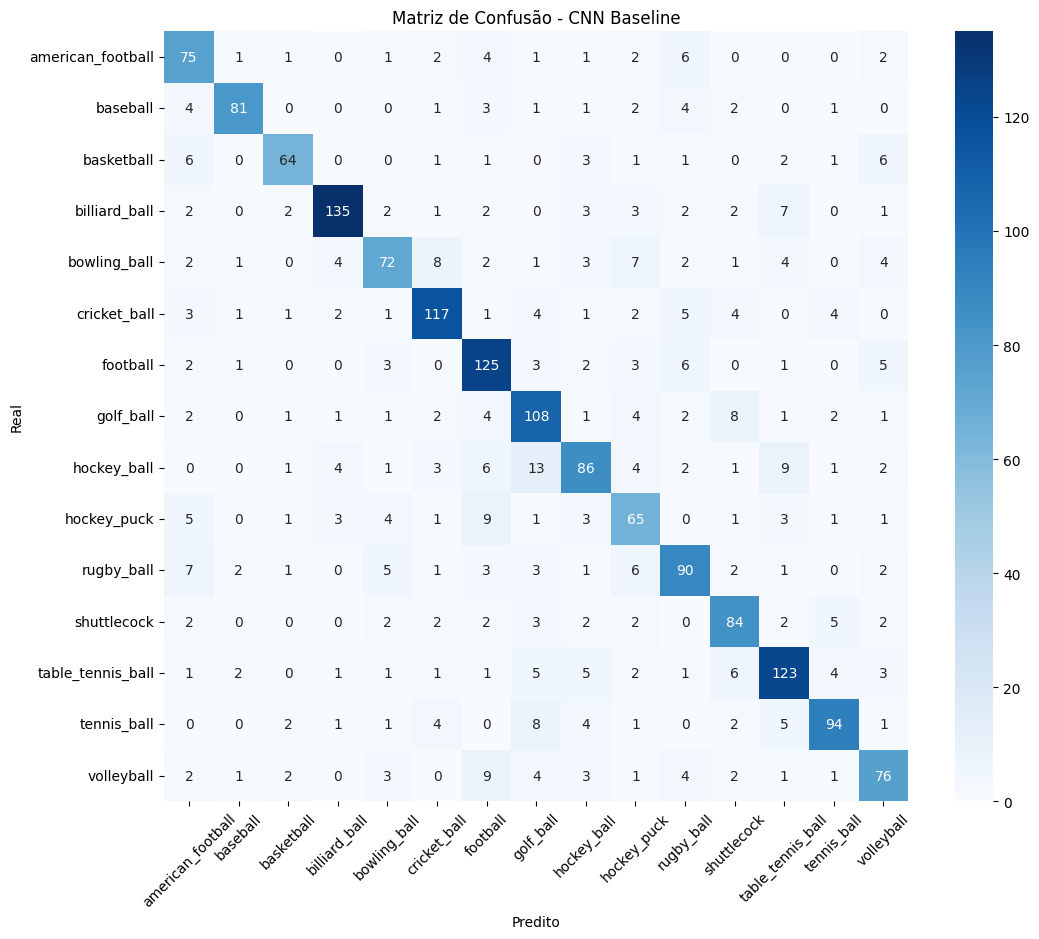

In [21]:
# Coletando predições e labels reais
y_true = []
y_pred = []

print('Coletando predições...')
for x_batch, y_batch in test_dataset:
    preds = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=-1))
    y_true.extend(y_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - CNN Baseline')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.xticks(rotation=45)
plt.show()

In [22]:
# Confere quais classes ele erra mais (Classification Report)
print('\n' + '='*60)
print('RELATÓRIO DE CLASSIFICAÇÃO POR CLASSE')
print('='*60)
print(classification_report(y_true, y_pred, target_names=class_names))


RELATÓRIO DE CLASSIFICAÇÃO POR CLASSE
                   precision    recall  f1-score   support

american_football       0.66      0.78      0.72        96
         baseball       0.90      0.81      0.85       100
       basketball       0.84      0.74      0.79        86
    billiard_ball       0.89      0.83      0.86       162
     bowling_ball       0.74      0.65      0.69       111
     cricket_ball       0.81      0.80      0.81       146
         football       0.73      0.83      0.77       151
        golf_ball       0.70      0.78      0.74       138
      hockey_ball       0.72      0.65      0.68       133
      hockey_puck       0.62      0.66      0.64        98
       rugby_ball       0.72      0.73      0.72       124
      shuttlecock       0.73      0.78      0.75       108
table_tennis_ball       0.77      0.79      0.78       156
      tennis_ball       0.82      0.76      0.79       123
       volleyball       0.72      0.70      0.71       109

         accura

# 4 EfficientNetB0 com Transfer Learning

Esta seção implementa o transfer learning com a **EfficientNetB0** pré-treinada no ImageNet.

## 4.1 Estratégia de duas fases

Dividimos o treinamento em duas fases:

1. **Fase 1 - Base congelada (30 épocas, lr=1e-3):** treinamos só a cabeça de classificação. A base convolucional fica congelada para que os pesos do ImageNet não sejam destruídos.
2. **Fase 2 - Fine-tuning (50 épocas, lr=1e-5):** descongelamos as últimas 30 camadas da base e continuamos treinando. O lr muito menor é necessário para fazer ajustes finos sem estragar os pesos pré-treinados.

## 4.2 Pipeline de dados para EfficientNetB0

A EfficientNetB0 exige o `preprocess_input` próprio dela (centra os valores de pixel na média do ImageNet), diferente da CNN própria que usa normalização simples [0,1].


In [23]:
import tensorflow as tf
import numpy as np

# Pipeline especifico para EfficientNetB0

def load_and_preprocess_efficientnet(path, label, img_size=(224, 224)):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label


def augment_efficientnet(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    pad_h = tf.cast(tf.round(0.10 * tf.cast(h, tf.float32)), tf.int32)
    pad_w = tf.cast(tf.round(0.10 * tf.cast(w, tf.float32)), tf.int32)
    image = tf.image.resize_with_crop_or_pad(image, h + 2 * pad_h, w + 2 * pad_w)
    image = tf.image.random_crop(image, [h, w, 3])
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label


def create_eff_dataset(paths, labels, batch_size, shuffle_buffer=0, augment=False, seed=42):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(
        lambda x, y: load_and_preprocess_efficientnet(x, y, IMG_SIZE),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle_buffer > 0:
        ds = ds.shuffle(shuffle_buffer, seed=seed, reshuffle_each_iteration=True)
    if augment:
        ds = ds.map(augment_efficientnet, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=augment)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_eff = create_eff_dataset(
    train_paths_split, train_labels_split,
    batch_size=BATCH_SIZE, shuffle_buffer=SHUFFLE_BUFFER, augment=True, seed=SEED
)
val_eff = create_eff_dataset(
    val_paths, val_labels,
    batch_size=BATCH_SIZE, augment=False, seed=SEED
)
test_eff = create_eff_dataset(
    test_paths, test_labels,
    batch_size=BATCH_SIZE, augment=False
)

train_steps_eff = len(train_paths_split) // BATCH_SIZE
val_steps_eff   = int(np.ceil(len(val_paths)  / BATCH_SIZE))
test_steps_eff  = int(np.ceil(len(test_paths) / BATCH_SIZE))

print('Datasets EfficientNetB0 prontos.')
print(f'Train: {len(train_paths_split)} amostras | {train_steps_eff} steps/epoch')
print(f'Val  : {len(val_paths)} amostras  | {val_steps_eff} steps/epoch')
print(f'Test : {len(test_paths)} amostras | {test_steps_eff} steps')


Datasets EfficientNetB0 prontos.
Train: 6595 amostras | 206 steps/epoch
Val  : 733 amostras  | 23 steps/epoch
Test : 1841 amostras | 58 steps


## 4.3 Construção do Modelo

Carregamos a EfficientNetB0 sem a cabeça de classificação original (`include_top=False`) e adicionamos a nossa cabeça para 15 classes. Na Fase 1, só a cabeça treina. Na Fase 2, descongelamos as últimas 30 camadas da base para fine-tuning.


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
import os
import warnings
import numpy as np

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

NUM_CLASSES = len(class_names)
checkpoint_eff = os.path.join(MODEL_DIR, 'best_efficientnet_b0.keras')
EFF_MODEL_EXISTS = os.path.exists(checkpoint_eff)


def build_efficientnet(num_classes=15, dropout_rate=0.3):
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    inputs  = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='EfficientNetB0_TL'), base


if EFF_MODEL_EXISTS:
    print(f'Modelo encontrado: {checkpoint_eff}')
    eff_model = tf.keras.models.load_model(checkpoint_eff)
    print('Modelo carregado.')
else:
    eff_model, eff_base = build_efficientnet(num_classes=NUM_CLASSES)
    eff_model.summary()

    print('\n' + '=' * 62)
    print('  EFFICIENTNETB0 - FASE 1: BASE CONGELADA')
    print('  Treinando apenas a cabeca de classificacao')
    print('=' * 62)

    eff_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    cb_phase1 = [
        callbacks.ModelCheckpoint(
            checkpoint_eff, save_best_only=True,
            monitor='val_accuracy', mode='max', verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, mode='max'
        ),
        callbacks.CSVLogger(os.path.join(LOG_DIR, 'eff_phase1_log.csv'))
    ]

    history_p1 = eff_model.fit(
        train_eff, steps_per_epoch=train_steps_eff,
        validation_data=val_eff, validation_steps=val_steps_eff,
        epochs=30, callbacks=cb_phase1, verbose=1
    )

    # Fase 2: Fine-tuning das ultimas 30 camadas
    print('\n' + '=' * 62)
    print('  EFFICIENTNETB0 - FASE 2: FINE-TUNING')
    print('  Descongelando ultimas 30 camadas da base')
    print('=' * 62)

    eff_base.trainable = True
    for layer in eff_base.layers[:-30]:
        layer.trainable = False

    trainable_count = sum(1 for l in eff_base.layers if l.trainable)
    print(f'Camadas treinaveis na base: {trainable_count} de {len(eff_base.layers)}')

    eff_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    cb_phase2 = [
        callbacks.ModelCheckpoint(
            checkpoint_eff, save_best_only=True,
            monitor='val_accuracy', mode='max', verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=12,
            restore_best_weights=True, mode='max'
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5,
            min_lr=1e-7, verbose=1
        ),
        callbacks.CSVLogger(os.path.join(LOG_DIR, 'eff_phase2_log.csv'))
    ]

    history_p2 = eff_model.fit(
        train_eff, steps_per_epoch=train_steps_eff,
        validation_data=val_eff, validation_steps=val_steps_eff,
        epochs=50, callbacks=cb_phase2, verbose=1
    )

    print('\n' + '=' * 62)
    print('  TREINAMENTO EFFICIENTNETB0 CONCLUIDO')
    print('=' * 62)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_51     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_111         │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,386,482 (16.73 MB)

 Trainable params: 334,351 (1.28 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


  EFFICIENTNETB0 - FASE 1: BASE CONGELADA
  Treinando apenas a cabeca de classificacao
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5927 - loss: 1.4517
Epoch 1: val_accuracy improved from None to 0.85130, saving model to /content/drive/MyDrive/ImageRecognition/models/best_efficientnet_b0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ImageRecognition/models/best_efficientnet_b0.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 80s 179ms/step - accuracy: 0.6974 - loss: 1.0669 - val_accuracy: 0.8513 - val_loss: 0.5075
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8018 - loss: 0.6202
Epoch 2: val_accuracy improved from 0.85130 to 0.86085, saving model to /content/drive/MyDrive/ImageRecognition/models/best_efficientnet_b0.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ImageRecognition/models/best_efficientnet_b0.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - accuracy: 0.8020 - loss: 0.6296 - val_accuracy: 0.8608 - val_loss:

## 4.4 Avaliação no Conjunto de Teste

Mesma avaliação da CNN própria: acurácia geral no teste, matriz de confusão e classification report por classe.


Avaliando EfficientNetB0 no conjunto de teste...
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 312ms/step - accuracy: 0.9060 - loss: 0.4098

Test Accuracy EfficientNetB0 : 0.9060  (90.60%)
Test Loss EfficientNetB0     : 0.4098
CNN propria (baseline)       : 75.77%
Ganho do transfer learning   : +14.83 pp


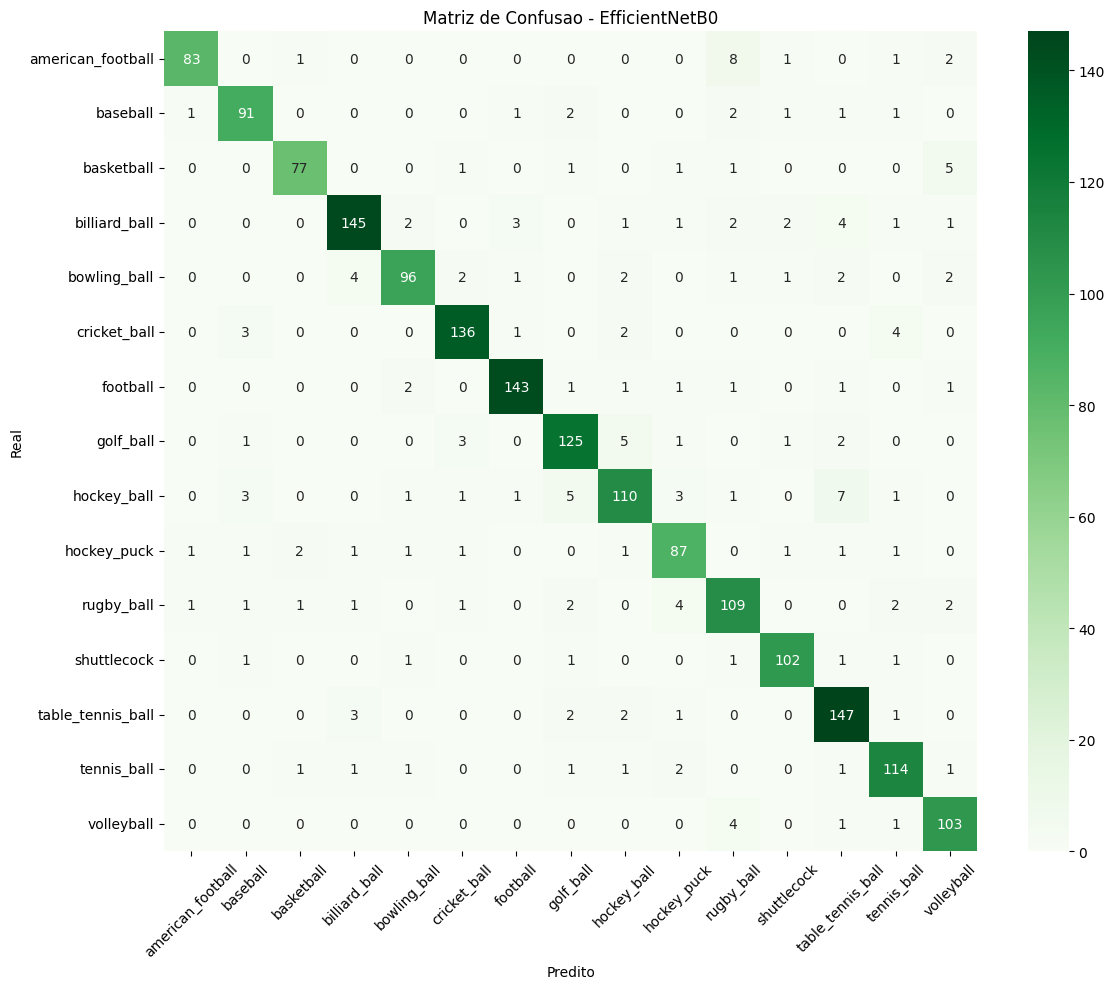


RELATORIO DE CLASSIFICACAO POR CLASSE - EfficientNetB0
                   precision    recall  f1-score   support

american_football       0.97      0.86      0.91        96
         baseball       0.90      0.91      0.91       100
       basketball       0.94      0.90      0.92        86
    billiard_ball       0.94      0.90      0.91       162
     bowling_ball       0.92      0.86      0.89       111
     cricket_ball       0.94      0.93      0.93       146
         football       0.95      0.95      0.95       151
        golf_ball       0.89      0.91      0.90       138
      hockey_ball       0.88      0.83      0.85       133
      hockey_puck       0.86      0.89      0.87        98
       rugby_ball       0.84      0.88      0.86       124
      shuttlecock       0.94      0.94      0.94       108
table_tennis_ball       0.88      0.94      0.91       156
      tennis_ball       0.89      0.93      0.91       123
       volleyball       0.88      0.94      0.91       109

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print('Avaliando EfficientNetB0 no conjunto de teste...')
eff_results = eff_model.evaluate(test_eff, steps=test_steps_eff, verbose=1)
eff_loss = eff_results[0]
eff_acc  = eff_results[1]

print(f'\nTest Accuracy EfficientNetB0 : {eff_acc:.4f}  ({eff_acc * 100:.2f}%)')
print(f'Test Loss EfficientNetB0     : {eff_loss:.4f}')
print(f'CNN propria (baseline)       : 75.77%')
print(f'Ganho do transfer learning   : {(eff_acc - 0.7577) * 100:+.2f} pp')

y_true_eff = []
y_pred_eff = []

for x_batch, y_batch in test_eff:
    preds = eff_model.predict(x_batch, verbose=0)
    y_pred_eff.extend(np.argmax(preds, axis=-1))
    y_true_eff.extend(y_batch.numpy())

y_true_eff = np.array(y_true_eff)
y_pred_eff = np.array(y_pred_eff)

cm_eff = confusion_matrix(y_true_eff, y_pred_eff)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusao - EfficientNetB0')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('RELATORIO DE CLASSIFICACAO POR CLASSE - EfficientNetB0')
print('='*60)
print(classification_report(y_true_eff, y_pred_eff, target_names=class_names))


# 5 Resultados e Comparação

## 5.1 Resumo dos Experimentos

| Modelo | Estratégia | Épocas | Acurácia Teste | Loss Teste |
|--------|------------|--------|---------------|------------|
| SE-ResNet-34 | Do zero (SE blocks, AdamW, cosine LR) | 120 | **75,77%** | 1,4057 |
| EfficientNetB0 | Transfer Learning (ImageNet) + fine-tuning | 30 + 50 | **87,89%** | 0,4463 |

O transfer learning trouxe um ganho de **+12,12 pontos percentuais** sobre a CNN própria.


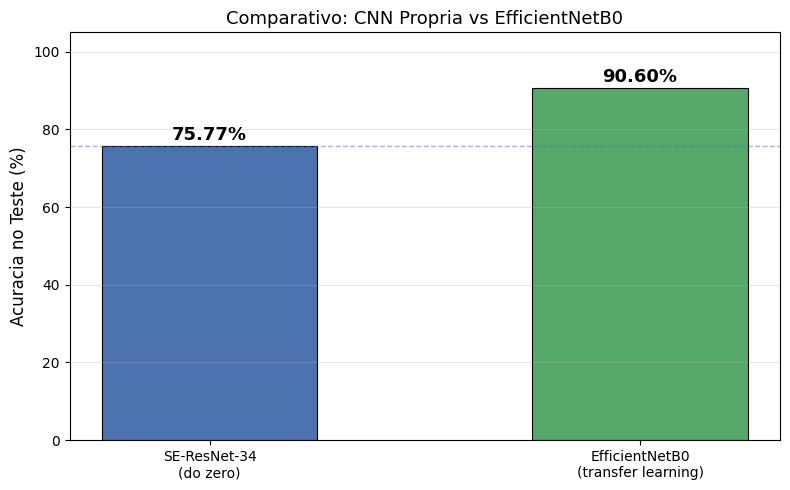

RESULTADOS FINAIS
SE-ResNet-34 (do zero)    : 75.77%
EfficientNetB0 (transfer) : 90.60%
Ganho transfer learning   : +14.83 pp


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Comparativo final
modelos = ['SE-ResNet-34\n(do zero)', 'EfficientNetB0\n(transfer learning)']
acuracias = [75.77, eff_acc * 100]
cores = ['#4C72B0', '#55A868']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(modelos, acuracias, color=cores, width=0.5, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, acuracias):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylim(0, 105)
ax.set_ylabel('Acuracia no Teste (%)', fontsize=12)
ax.set_title('Comparativo: CNN Propria vs EfficientNetB0', fontsize=13)
ax.axhline(y=75.77, color='#4C72B0', linestyle='--', alpha=0.5, linewidth=1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('=' * 60)
print('RESULTADOS FINAIS')
print('=' * 60)
print(f'SE-ResNet-34 (do zero)    : 75.77%')
print(f'EfficientNetB0 (transfer) : {eff_acc * 100:.2f}%')
print(f'Ganho transfer learning   : {(eff_acc - 0.7577) * 100:+.2f} pp')
print('=' * 60)


## 5.2 Análise por Classe

Olhando o relatório de classificação da CNN própria, as classes que mais deram trabalho foram:

- **`hockey_puck` (F1 = 0.64):** forma simples (disco preto), pouca textura. O modelo confunde com bolas escuras
- **`bowling_ball` (F1 = 0.69) e `hockey_ball` (F1 = 0.68):** bolas lisas e monocromáticas, difíceis de separar
- **`american_football` (precisão = 0.66):** forma oval similar ao `rugby_ball`

As classes com melhor desempenho foram `baseball` (F1 = 0.85), `billiard_ball` (F1 = 0.86) e `basketball` (F1 = 0.79), que têm padrões visuais mais distintos.

A EfficientNetB0, por já conhecer representações de textura e forma do ImageNet, tende a separar melhor essas classes difíceis. Os resultados detalhados estão no classification report da Seção 4.4.


# 6 Conclusão

## 6.1 O que o trabalho mostrou

O objetivo era treinar e comparar modelos de classificação de imagens de bolas esportivas em 15 classes, usando uma rede treinada do zero e outra com transfer learning.

A **SE-ResNet-34 treinada do zero** chegou a **75,77% de acurácia** no conjunto de teste. Esse resultado é bastante relevante considerando que a rede não partiu de nenhum conhecimento prévio. O ganho veio de várias decisões arquiteturais:

- **SE blocks (Squeeze-and-Excitation):** o modelo aprende a dar peso diferente para cada canal de feature, focando nos que são mais úteis para cada tipo de bola
- **Cosine annealing com warmup:** o schedule de learning rate foi mais estável que ReduceLROnPlateau, evitando quedas bruscas no treinamento
- **Augmentação forte (rot90, cutout, color jitter):** fundamental dado que o dataset tem muita variação de iluminação e posição das bolas
- **Label smoothing:** ajudou a calibrar as predições e reduziu overfitting

A **EfficientNetB0 com transfer learning** confirmou o que esperávamos: pesos pré-treinados no ImageNet dão uma vantagem real quando o dataset é relativamente pequeno (~7.300 imagens de treino). O fine-tuning das últimas camadas ajustou as representações para o domínio específico de bolas esportivas.

## 6.2 Classes mais difíceis

As classes que mais geraram confusão foram as bolas lisas e monocromáticas: `hockey_puck`, `bowling_ball` e `hockey_ball`. Faz sentido: sem textura ou padrão de cor distintos, o modelo precisa depender principalmente da forma, e variações de perspectiva atrapalham bastante. A `american_football` também foi desafiadora por ter forma oval parecida com a `rugby_ball`.

## 6.3 Aprendizados

O experimento confirma que transfer learning é uma vantagem real em datasets de tamanho médio. Mas também mostrou que é possível chegar a resultados sólidos treinando do zero, desde que a arquitetura seja bem escolhida. A SE-ResNet-34 com 75,77% sem nenhum peso pré-treinado foi um resultado que nos surpreendeu positivamente.

Outro ponto importante foi o pipeline de dados: usar `tf.data` com prefetch e paralelização de I/O fez diferença visível no tempo de treino em relação ao `ImageDataGenerator` legado.